# US Wildfire Size Classification — Baseline Models

Three baselines in order of sophistication:

| # | Model | Purpose |
|---|---|---|
| 1 | **Dummy (most-frequent)** | Exposes why accuracy is a bad metric on imbalanced data |
| 2 | **Logistic Regression** | Linear probabilistic baseline |
| 3 | **Decision Tree** | Non-linear, interpretable baseline |

All three share the same preprocessing pipeline from `Preprocessing.py`.  
Evaluation: **stratified 5-fold CV** → accuracy, precision, recall, F1, ROC-AUC (all macro-averaged).

In [1]:
import os, sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    precision_score, recall_score, f1_score, roc_auc_score,
)

sys.path.insert(0, "..")
from Preprocessing import build_pipeline, load_and_split

DATA_PATH   = os.path.join("..", "data", "FW_Veg_Rem_Combined.csv")
OUTPUTS_DIR = os.path.join("..", "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

## 1  Load data & inspect class imbalance

In [2]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Download it with:\n"
        "  pip install kagglehub\n"
        "  python -c \"import kagglehub, shutil, os; "
        "path = kagglehub.dataset_download('capcloudcoder/us-wildfire-data-plus-other-attributes'); "
        "shutil.copy(os.path.join(path, 'FW_Veg_Rem_Combined.csv'), '../data/')\""
    )

X_train, X_val, X_test, y_train, y_val, y_test = load_and_split(DATA_PATH)

Split  →  train: 38,756  |  val: 8,305  |  test: 8,306
Class distribution (train):
fire_size_class
B    0.660
C    0.195
G    0.072
F    0.036
D    0.025
E    0.013
Name: proportion, dtype: float64



In [3]:
# ── Class distribution ──────────────────────────────────────────────────────
dist = y_train.value_counts().sort_index()
dist_pct = dist / dist.sum()

majority_class = dist_pct.idxmax()
majority_pct   = dist_pct.max()

print(f"Training samples : {len(y_train):,}")
print()
print("Class  Count    Share")
print("-" * 28)
for cls in dist.index:
    flag = "  ← majority" if cls == majority_class else ""
    print(f"  {cls}    {dist[cls]:>6,}   {dist_pct[cls]:>6.1%}{flag}")
print()
print(f"Dummy accuracy ceiling : {majority_pct:.1%}")
print(f"  → A classifier that always predicts '{majority_class}' gets {majority_pct:.1%} accuracy")
print(f"    while being completely useless for detecting larger fires.")

Training samples : 38,756

Class  Count    Share
----------------------------
  B    25,565    66.0%  ← majority
  C     7,567    19.5%
  D       976     2.5%
  E       490     1.3%
  F     1,378     3.6%
  G     2,780     7.2%

Dummy accuracy ceiling : 66.0%
  → A classifier that always predicts 'B' gets 66.0% accuracy
    while being completely useless for detecting larger fires.


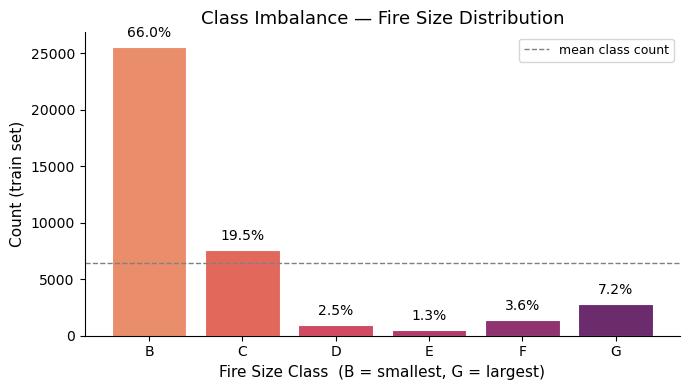

Saved → outputs/class_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
palette = sns.color_palette("flare", len(dist))
bars = ax.bar(dist.index, dist.values, color=palette, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in dist_pct.values], padding=5, fontsize=10)
ax.set_xlabel("Fire Size Class  (B = smallest, G = largest)", fontsize=11)
ax.set_ylabel("Count (train set)", fontsize=11)
ax.set_title("Class Imbalance — Fire Size Distribution", fontsize=13)
ax.axhline(dist.mean(), color="gray", linestyle="--", linewidth=1, label="mean class count")
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "class_distribution.png"), dpi=150)
plt.show()
print("Saved → outputs/class_distribution.png")

## 2  Why accuracy fails here

Class B (small fires) dominates the dataset. A classifier that **always** outputs `B` achieves
roughly the majority-class share in accuracy — with zero knowledge of the problem.

Macro-averaged metrics weight every class equally regardless of frequency, exposing a model that
ignores minority classes:

| Metric | Dummy gets | Penalty mechanism |
|---|---|---|
| Accuracy | ~majority % | None — majority vote wins |
| Precision (macro) | ~1/k | 0 for every non-predicted class |
| Recall (macro) | ~1/k | 0 recall on all minority classes |
| F1 (macro) | ~1/k | Harmonic mean of the above |
| ROC-AUC (OVR macro) | 0.50 | Constant scores → random discrimination |

where *k* = 6 classes, so the ceiling for a dummy model on the real metrics is roughly **17%**.

## 3  Cross-validation setup

In [5]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Custom scorers with zero_division=0 so undefined precision/recall
# (classes never predicted) score as 0 rather than raising a warning.
scoring = {
    "accuracy":        "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro":    make_scorer(recall_score,    average="macro", zero_division=0),
    "f1_macro":        make_scorer(f1_score,        average="macro", zero_division=0),
    # response_method replaces the deprecated needs_proba (removed in sklearn 1.5+)
    "roc_auc_ovr":     make_scorer(
                           roc_auc_score,
                           response_method="predict_proba",
                           multi_class="ovr",
                           average="macro",
                       ),
}

METRIC_MAP = {
    "test_accuracy":        "Accuracy",
    "test_precision_macro": "Precision (macro)",
    "test_recall_macro":    "Recall (macro)",
    "test_f1_macro":        "F1 (macro)",
    "test_roc_auc_ovr":     "ROC-AUC (OVR macro)",
}

print(f"CV strategy : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)")
print(f"Metrics     : {', '.join(METRIC_MAP.values())}")

CV strategy : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Metrics     : Accuracy, Precision (macro), Recall (macro), F1 (macro), ROC-AUC (OVR macro)


## 4  Define models

In [ ]:
# Combine train + val for CV (test set untouched until final evaluation)
X_cv = pd.concat([X_train, X_val], ignore_index=True)
y_cv = pd.concat([y_train, y_val], ignore_index=True)
print(f"CV pool : {len(X_cv):,} samples  ({len(X_cv)/len(pd.concat([X_train,X_val,X_test])):.0%} of full dataset)")

models = {
    "Dummy (most-frequent)": DummyClassifier(
        strategy="most_frequent",
        random_state=42,
    ),
    # saga handles the large OHE feature space (50 states + vegetation codes)
    # much better than lbfgs on datasets of this size
    "Logistic Regression": LogisticRegression(
        max_iter=1_000,
        C=1.0,
        solver="saga",
        random_state=42,
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        # Unrestricted depth — intentional: lets us observe overfitting
        # behaviour in the baseline before tuning.
    ),
}

## 5  Run stratified cross-validation

In [7]:
def run_cv(name, clf, X, y):
    """Fit a full pipeline in cross-validation and return per-fold scores."""
    pipeline = build_pipeline(clf)
    print(f"  {name:<28s}", end="", flush=True)
    raw = cross_validate(pipeline, X, y, cv=CV, scoring=scoring, n_jobs=-1)
    print("done")
    return raw


print("Running 5-fold CV (n_jobs=-1) …")
cv_results = {name: run_cv(name, clf, X_cv, y_cv) for name, clf in models.items()}
print("\nAll done.")

Running 5-fold CV (n_jobs=-1) …
  Dummy (most-frequent)       

done
  Logistic Regression         

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


done
  Decision Tree               

done

All done.


## 6  Results

In [8]:
# ── Per-fold scores (raw) ────────────────────────────────────────────────────
fold_rows = []
for model_name, raw in cv_results.items():
    for fold_idx in range(CV.get_n_splits()):
        row = {"Model": model_name, "Fold": fold_idx + 1}
        for key, label in METRIC_MAP.items():
            row[label] = raw[key][fold_idx]
        fold_rows.append(row)

fold_df = pd.DataFrame(fold_rows).set_index(["Model", "Fold"])
print("Per-fold scores:")
fold_df

Per-fold scores:


Accuracy  Precision (macro)  Recall (macro)  \
Model                 Fold                                                
Dummy (most-frequent) 1     0.659620           0.109937        0.166667   
                      2     0.659690           0.109948        0.166667   
                      3     0.659690           0.109948        0.166667   
                      4     0.659584           0.109931        0.166667   
                      5     0.659584           0.109931        0.166667   
Logistic Regression   1     0.709551           0.289299        0.290641   
                      2     0.710582           0.362960        0.294380   
                      3     0.708032           0.323565        0.286604   
                      4     0.707820           0.316537        0.288045   
                      5     0.708351           0.325852        0.289374   
Decision Tree         1     0.597259           0.335764        0.341452   
                      2     0.595516           0.341877        0.344221   
                      3     0.606354           0.346978        0.348076   
                      4     0.610285           0.345300        0.347111   
                      5     0.604972           0.345783        0.345197   

                            F1 (macro)  ROC-AUC (OVR macro)  
Model                 Fold                                   
Dummy (most-frequent) 1       0.132484             0.500000  
                      2       0.132493             0.500000  
                      3       0.132493             0.500000  
                      4       0.132480             0.500000  
                      5       0.132480             0.500000  
Logistic Regression   1       0.257267             0.784532  
                      2       0.264917             0.774078  
                      3       0.255334             0.770895  
                      4       0.254976             0.768986  
                      5       0.258019             0.772361  
Decision Tree         1       0.338397             0.608576  
                      2       0.342745             0.610248  
                      3       0.347460             0.613088  
                      4       0.346105             0.613413  
                      5       0.345313             0.611570

In [9]:
# ── Summary: mean ± std ──────────────────────────────────────────────────────
summary_rows = []
for model_name, raw in cv_results.items():
    row = {"Model": model_name}
    for key, label in METRIC_MAP.items():
        scores = raw[key]
        row[label] = f"{scores.mean():.4f} ± {scores.std():.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")

divider = "=" * 90
print(divider)
print("  Stratified 5-Fold CV Results   (mean ± std across folds)")
print(divider)
print(summary_df.to_string())
print(divider)

summary_df

  Stratified 5-Fold CV Results   (mean ± std across folds)
                              Accuracy Precision (macro)   Recall (macro)       F1 (macro) ROC-AUC (OVR macro)
Model                                                                                                         
Dummy (most-frequent)  0.6596 ± 0.0000   0.1099 ± 0.0000  0.1667 ± 0.0000  0.1325 ± 0.0000     0.5000 ± 0.0000
Logistic Regression    0.7089 ± 0.0010   0.3236 ± 0.0236  0.2898 ± 0.0027  0.2581 ± 0.0036     0.7742 ± 0.0054
Decision Tree          0.6029 ± 0.0056   0.3431 ± 0.0041  0.3452 ± 0.0023  0.3440 ± 0.0032     0.6114 ± 0.0018


,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OVR macro)
Model,,,,,
Dummy (most-frequent),0.6596 ± 0.0000,0.1099 ± 0.0000,0.1667 ± 0.0000,0.1325 ± 0.0000,0.5000 ± 0.0000
Logistic Regression,0.7089 ± 0.0010,0.3236 ± 0.0236,0.2898 ± 0.0027,0.2581 ± 0.0036,0.7742 ± 0.0054
Decision Tree,0.6029 ± 0.0056,0.3431 ± 0.0041,0.3452 ± 0.0023,0.3440 ± 0.0032,0.6114 ± 0.0018


In [10]:
# ── Mean scores as floats for visualisation ──────────────────────────────────
mean_df = pd.DataFrame(
    {
        label: [cv_results[m][key].mean() for m in models]
        for key, label in METRIC_MAP.items()
    },
    index=list(models.keys()),
)

std_df = pd.DataFrame(
    {
        label: [cv_results[m][key].std() for m in models]
        for key, label in METRIC_MAP.items()
    },
    index=list(models.keys()),
)

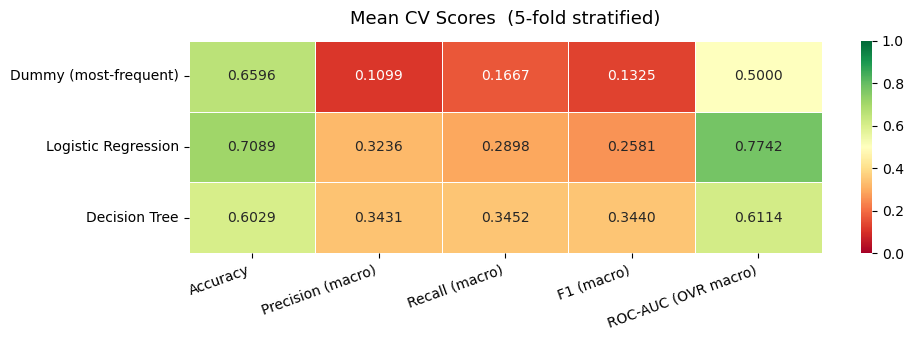

Saved → outputs/baseline_cv_heatmap.png


In [11]:
# ── Heatmap — mean scores ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(
    mean_df,
    annot=True, fmt=".4f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("Mean CV Scores  (5-fold stratified)", fontsize=13, pad=12)
ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "baseline_cv_heatmap.png"), dpi=150)
plt.show()
print("Saved → outputs/baseline_cv_heatmap.png")

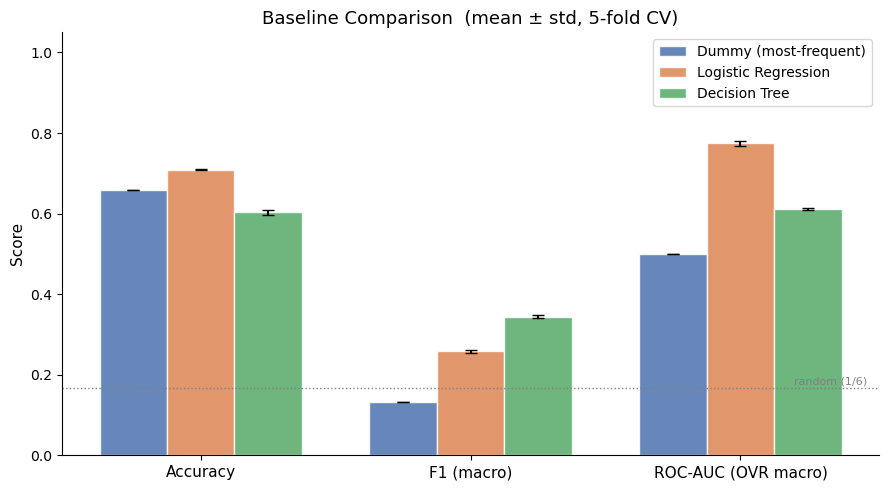

Saved → outputs/baseline_comparison.png


In [12]:
# ── Bar chart with error bars ─────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "F1 (macro)", "ROC-AUC (OVR macro)"]
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (model_name, color) in enumerate(zip(models.keys(), colors)):
    means = [mean_df.loc[model_name, m] for m in metrics_to_plot]
    stds  = [std_df.loc[model_name, m]  for m in metrics_to_plot]
    ax.bar(
        x + i * width, means, width,
        label=model_name,
        color=color, alpha=0.85, edgecolor="white",
        yerr=stds, capsize=4, error_kw={"elinewidth": 1.5},
    )

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Baseline Comparison  (mean ± std, 5-fold CV)", fontsize=13)
ax.legend(fontsize=10)
ax.axhline(1 / 6, color="gray", linestyle=":", linewidth=1)
ax.text(x[-1] + width + 0.2, 1/6 + 0.01, "random (1/6)", color="gray", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "baseline_comparison.png"), dpi=150)
plt.show()
print("Saved → outputs/baseline_comparison.png")

## 7  Key takeaways

**The dummy trap.** The dummy classifier will score high on accuracy (matching the ~66% class-B share)
but near-zero on F1 (macro) and ROC-AUC ≈ 0.50.  
This confirms that accuracy is not a useful optimisation target here.

**Logistic Regression.** A linear model provides a genuine signal over random; its macro-F1 and
ROC-AUC will comfortably beat the dummy.  Low variance across folds (small ± std) indicates stable
learning but possibly limited capacity for the non-linear relationships in the data.

**Decision Tree (unrestricted depth).** Likely achieves higher training accuracy than logistic
regression but shows more variance across folds — a sign of overfitting.  This motivates depth
constraints or ensemble methods (Random Forest, Gradient Boosting) in the next stage.

**Next steps:**
- Tune Decision Tree depth via the validation set
- Fit Random Forest / XGBoost as stronger baselines
- Use F1 (macro) or ROC-AUC as the primary selection metric, not accuracy